# Wind Turbine Experimental Data Visualization Tool

This notebook is designed to easily visualize various experimental data (resistance, power, voltage, current, etc.).

## How to Use
0. The Dataset should be uploaded here:
https://drive.google.com/drive/folders/115T7YsGx1EHJLYIa-piAbEpjV60-vW_y
1. Run the **[Setup & Load Data]** cell first. (New window would pop up. If it doesn't, stop the code and restart it)
2. Go to the **[2D Graph]** or **[3D Graph]** cells, change the variable names, and run them.
    * **2D Graph:** `graph_2d(load_data("filename.csv"), "Variable 1", "Variable 2", ...)`
   * **3D Graph:** `graph_3d(load_data("filename.csv"), "X-axis Variable", "Y-axis Variable", "Z-axis Variable")`
    * If your file is inside certain folder, for example **"test4.csv"** file in folder named **"testing_2-15-2026"** which should be under ".../WEC_Electronics/Data" then file name should be **"testing_2-15-2026/test4.csv"**.

## Available Variables (Column Names)
Copy and paste the names exactly as written below:
* `Time`
* `Set Resistance`
* `Set Voltage`
* `Set Current`
* `Set Power`
* `Load Resistance`
* `Load Voltage`
* `Load Current`
* `Load Power`
* `DAC Output`
* `Servo Position`
* `Wind Speed`

###1. Set up & Load Data
⬇️Click here


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.optimize import minimize
import glob
import os
from scipy.interpolate import make_interp_spline

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
def load_data(f):
    df = pd.read_csv("/content/drive/MyDrive/WEC_Electronics/Data/"+f)
    df["Time"] = (df["Time"]-df["Time"].iloc[0])
    return df

def processed_csv(df_raw, resample_interval='100ms'):
    df_clean = df_raw.copy()

    # 1. 시간 축 초기화 및 초(Second) 단위 변환
    df_clean["Time"] = df_clean["Time"] / 1000.0

    df_clean['Timedelta'] = pd.to_timedelta(df_clean['Time'], unit='s')
    df_clean = df_clean.set_index('Timedelta')

    df_clean = df_clean.drop(columns=['Time'])

    df_resampled = df_clean.resample(resample_interval).mean().interpolate()
    df_resampled['Time'] = df_resampled.index.total_seconds()

    df_resampled = df_resampled.reset_index(drop=True)

    cols = ['Time'] + [c for c in df_resampled.columns if c != 'Time']
    df_resampled = df_resampled[cols]

    df_resampled['Time'] = df_resampled['Time'].round(1)

    return df_resampled

def processing_graph(df, resample_interval='100ms'):
    df_clean = df.copy()

    # 1. 시간 축 초기화 및 초(Second) 단위 변환
    df_clean["Time"] = df_clean["Time"] / 1000.0

    # 2. IQR 기반 일반화된 이상치 제거
    # 시간 컬럼을 제외한 숫자형 컬럼만 선택
    num_cols = df_clean.select_dtypes(include=[np.number]).columns
    cols_to_check = [col for col in num_cols if col not in ["Time"]]

    # for col in cols_to_check:
    #     Q1 = df_clean[col].quantile(0.25)
    #     Q3 = df_clean[col].quantile(0.75)
    #     IQR = Q3 - Q1

    #     lower_bound = Q1 - 1.5 * IQR
    #     upper_bound = Q3 + 1.5 * IQR
    #     df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

    df_clean['Timedelta'] = pd.to_timedelta(df_clean['Time'], unit='s')
    df_clean = df_clean.set_index('Timedelta')

    # 지정된 간격(100ms = 0.1초)으로 평균 연산 후 결측치는 앞선 값으로 보간(ffill)
    # 시간 복잡도: O(N), N은 데이터 개수
    df_resampled = df_clean.resample(resample_interval).mean().interpolate()

    # 인덱스 리셋 및 정리
    df_resampled['Time'] = df_resampled['Time'].round(1)
    df_resampled = df_resampled.reset_index(drop=True)

    return df_resampled

def graph_2d(df_raw, *vars, timestart=0, timeend=10**30):
    df = df_raw[(df_raw["Time"] > timestart*1000) & (df_raw["Time"] < timeend*1000)].copy()
    plt.figure(figsize=(12, 6))
    for col in vars:
        plt.plot(df["Time"]/1000.0, df[col], label=col, linewidth=1.5)
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title(f"Time vs {', '.join(vars)}", fontweight='bold')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def graph_2d_bar(df, *vars, resample=1):
    plt.figure(figsize=(12, 6))
    interval_str = f"{int(resample * 1000)}ms"
    proc_df = processing_graph(df, resample_interval=interval_str)

    # 시간 축 데이터 추출
    x = proc_df["Time"].values
    for i, col in enumerate(vars):
        raw_x = df["Time"] / 1000.0
        raw_y = df[col]
        plt.plot(raw_x, raw_y, label=f"{col} (Raw)", color='black', alpha=0.3, linewidth=1.2)
        y = proc_df[col].values
        plt.bar(x, y, width=resample, align='edge', alpha=0.3, label=f"{col} (Binned)", color="tab:orange", edgecolor="darkorange", linewidth=1)
        if len(x) > 3:
            x_smooth = np.linspace(x.min(), x.max(), 500)
            spline = make_interp_spline(x, y, k=3)
            y_smooth = spline(x_smooth)
            y_smooth_clamped = np.maximum(y_smooth, 0.0)
            plt.plot(x_smooth, y_smooth_clamped, label=f"{col} (Smooth)", linewidth=2.5)
        else:
            # 데이터가 너무 적으면 그냥 꺾은선으로 출력
            plt.plot(x, y, marker='o', label=f"{col} (Line)", linewidth=2)
        #proc_df = processing_graph(df, resample_interval=str(resample*1000)+"ms")
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title(f"Time vs {', '.join(vars)}", fontweight='bold')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def graph_3d(df, x_col, y_col, z_col):

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # 3D Scatter plot (Color mapped to the Z-axis variable)
    sc = ax.scatter(df[x_col], df[y_col], df[z_col],
                    c=df[z_col], cmap='viridis', s=20, alpha=0.6)

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_zlabel(z_col)
    plt.title(f'3D Analysis: {x_col} vs {y_col} vs {z_col}', fontweight='bold')

    # Add a color bar
    plt.colorbar(sc, label=z_col)
    plt.show()


def graph_3dv2(df, x_col, y_col, z_col):
    """
    Usage: graph_3d('test1.csv', 'Load Resistance', 'Time', 'Load Power')
    """

    fig = px.scatter_3d(
        df,
        x=x_col,
        y=y_col,
        z=z_col,
        color=z_col,
        color_continuous_scale='Viridis',
        opacity=0.7,
        title=f'3D Analysis: {x_col} vs {y_col} vs {z_col}'
    )

    fig.update_traces(marker=dict(size=3))
    fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))

    fig.show()

In [ ]:
df1.columns

Index(['Time', 'ESTOP Pressed', 'Load Current', 'Load Power',
       'Load Resistance', 'Load Voltage', 'Output Voltage', 'PCC',
       'PCC Voltage', 'Power Mode', 'Resistance Mode', 'Servo Position',
       'Set Current', 'Set Power', 'State'],
      dtype='object')

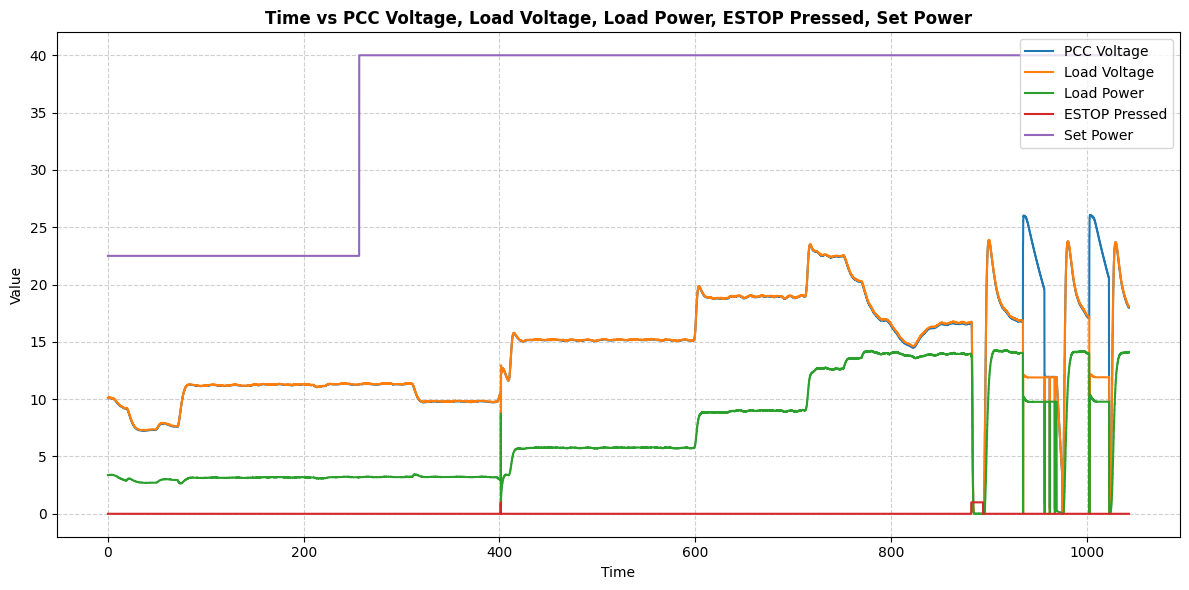

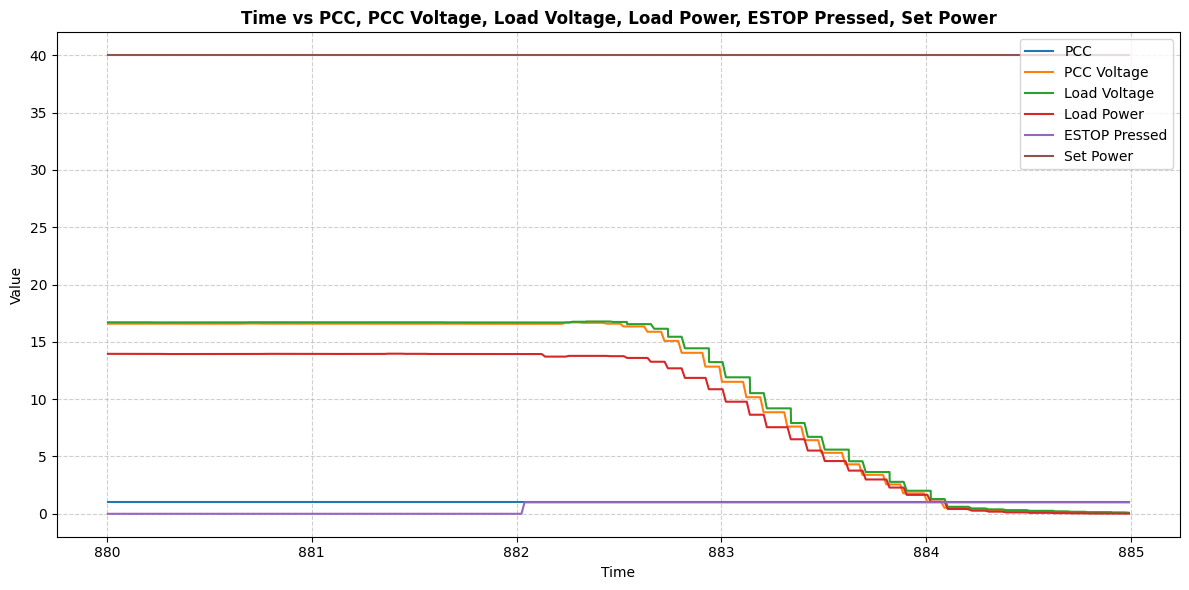

In [ ]:
df1 = load_data("testing-5-13/tunnel_testing_01.csv")
graph_2d(df1, "PCC Voltage", "Load Voltage", "Load Power", "ESTOP Pressed", "Set Power")

graph_2d(df1, "PCC", "PCC Voltage", "Load Voltage", "Load Power", "ESTOP Pressed", "Set Power", timestart = 880, timeend = 885)

In [ ]:
df1_temp = df1[(df1["Time"]>881*1000)&(df1["Time"]<885*1000)]
df1_temp.to_csv("Testing1_ESTOP.csv")

In [ ]:
processed_csv(df1_temp).to_csv("Testing1_ESTOP_100ms.csv")

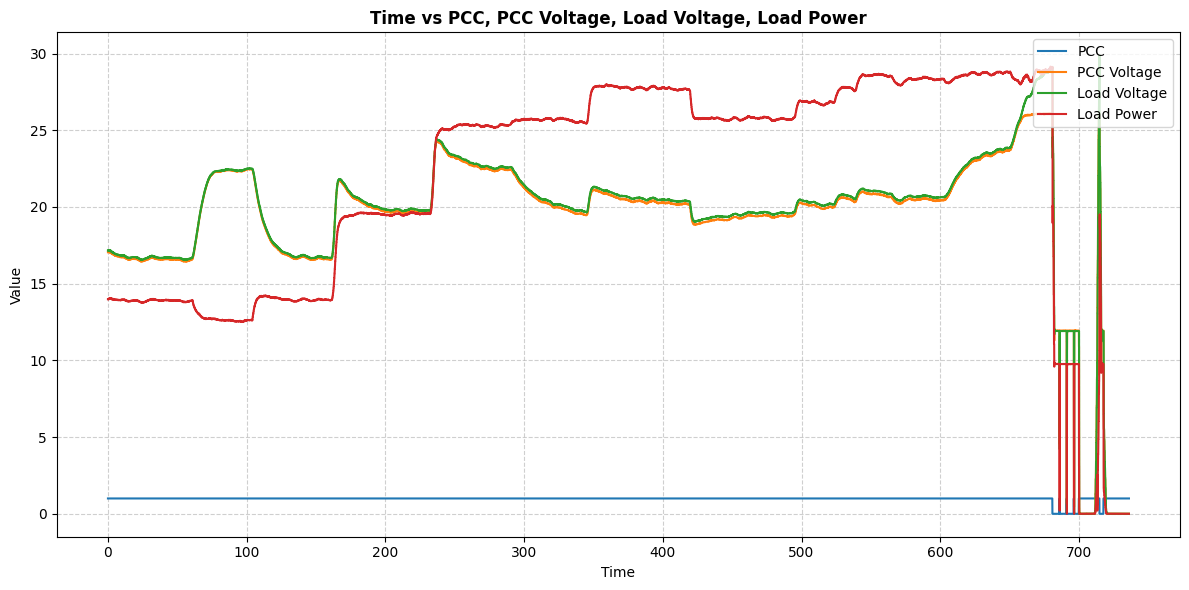

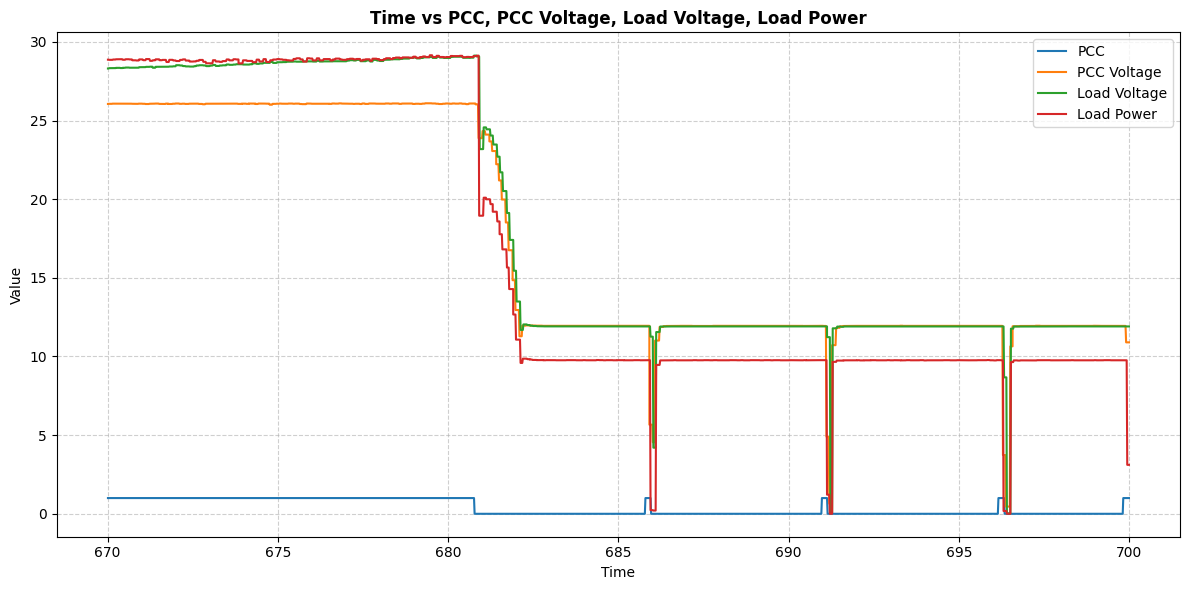

In [ ]:
df2 = load_data("testing-5-13/tunnel_testing_02.csv")
graph_2d(df2, "PCC", "PCC Voltage", "Load Voltage", "Load Power")

graph_2d(df2, "PCC", "PCC Voltage", "Load Voltage", "Load Power", timestart = 670, timeend = 700)

In [ ]:
df3 = load_data("testing-5-13/tunnel_testing_03.csv")

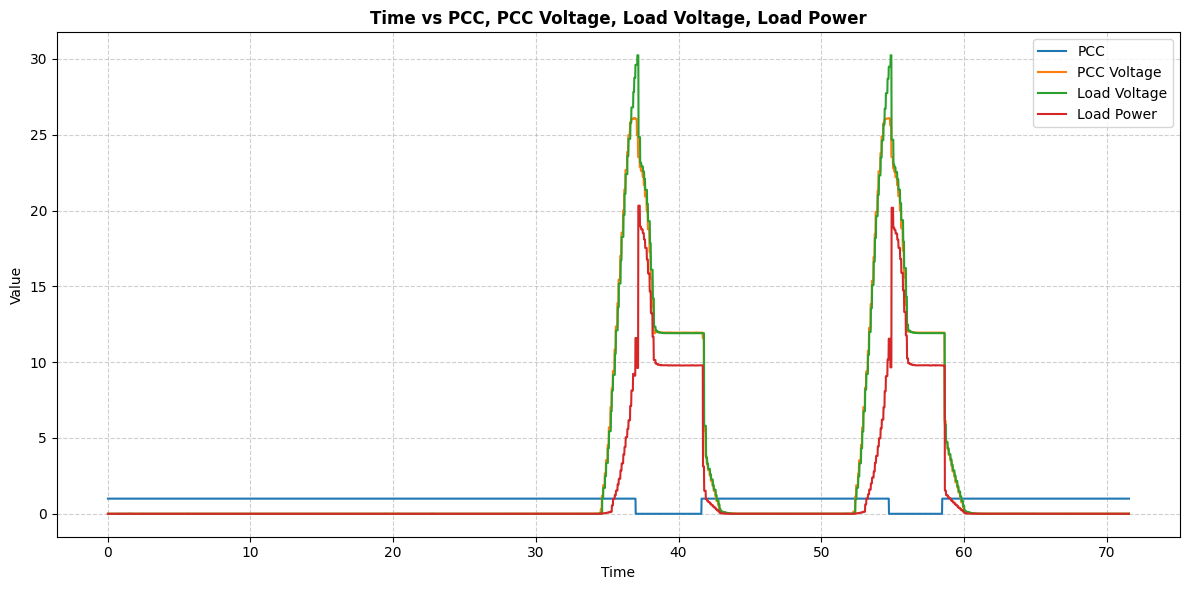

In [ ]:
graph_2d(df3, "PCC", "PCC Voltage", "Load Voltage", "Load Power") #

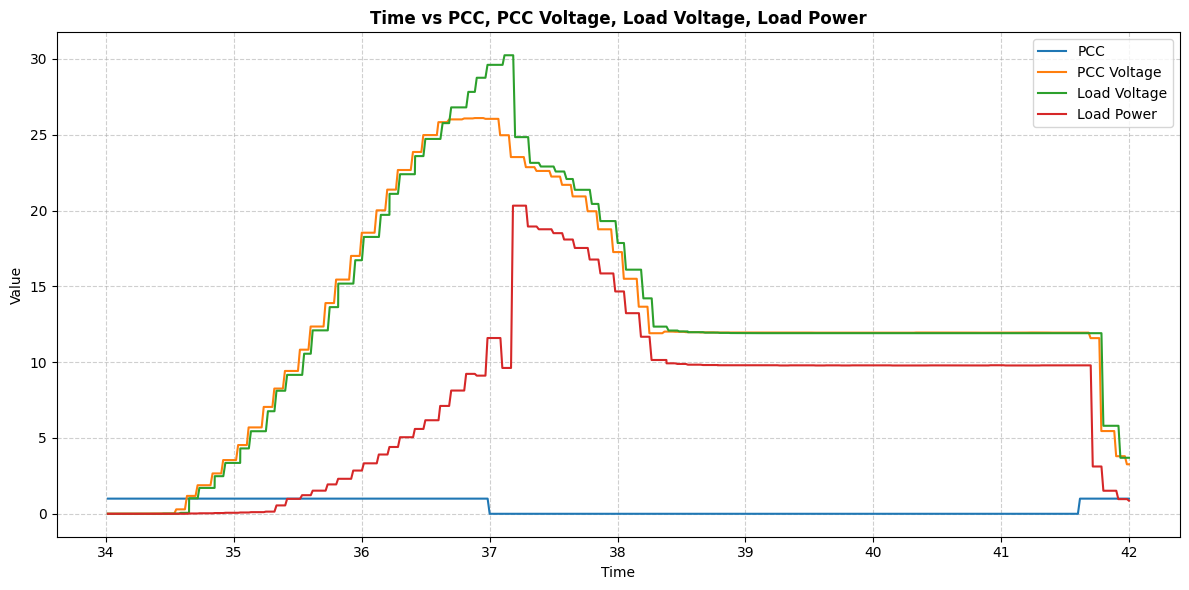

In [ ]:
graph_2d(df3, "PCC", "PCC Voltage", "Load Voltage", "Load Power", timestart = 34, timeend = 42)

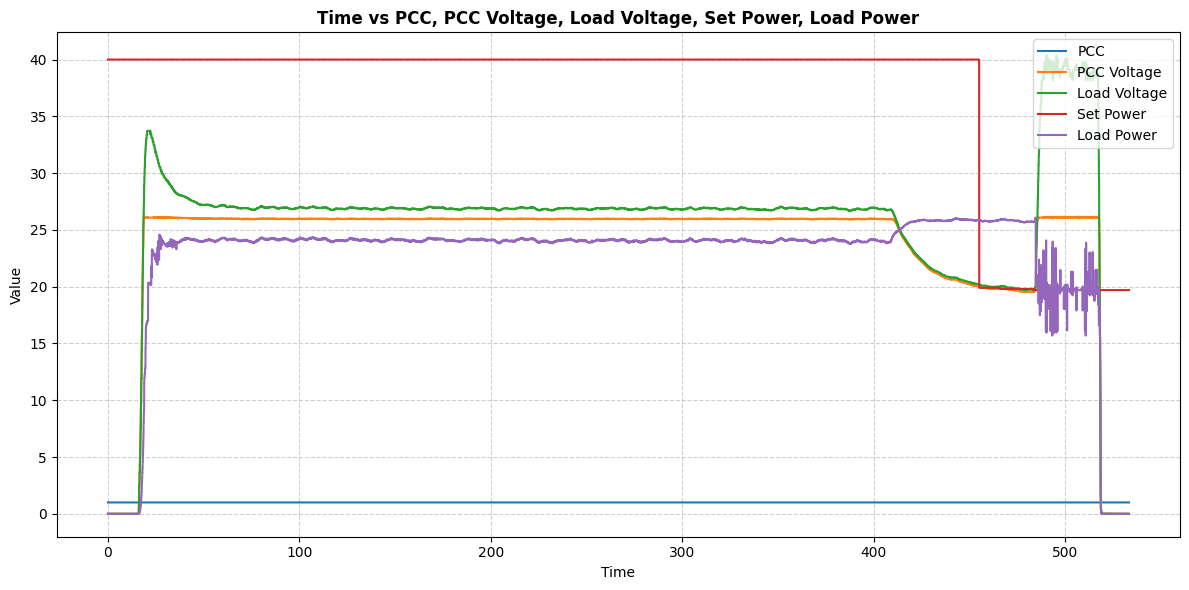

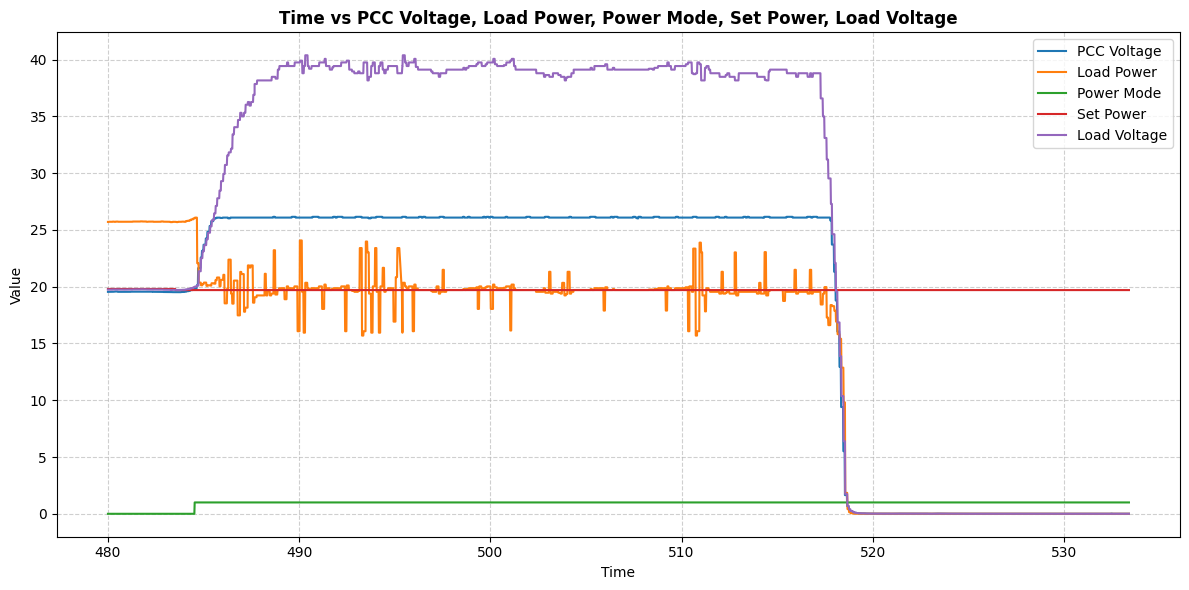

In [ ]:
df4 = load_data("testing-5-13/tunnel_testing_04.csv")
graph_2d(df4, "PCC", "PCC Voltage", "Load Voltage", "Set Power", "Load Power")

graph_2d(df4, "PCC Voltage", "Load Power", "Power Mode", "Set Power", "Load Voltage", timestart = 480)

In [ ]:
proc_df3 = processing_graph(df3, resample_interval="10000ms")
proc_df3 = proc_df3.iloc[30:60]

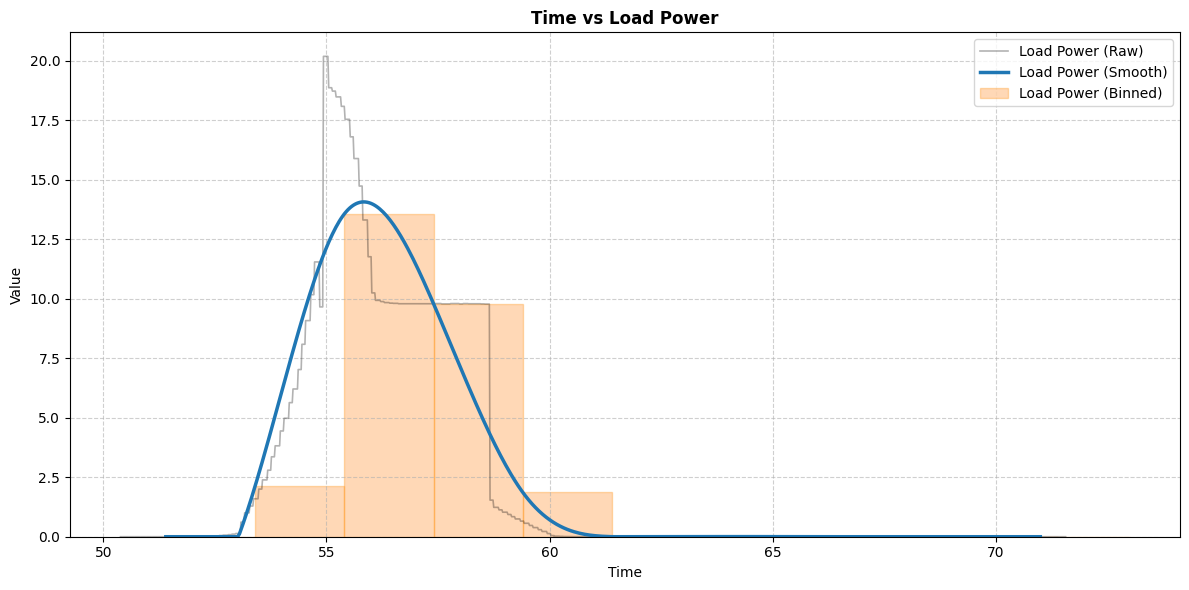

In [ ]:
graph_2d_bar(df3.iloc[6000:12000], "Load Power", resample=2)

In [ ]:
proc_df3.columns

Index(['Time', 'ESTOP Pressed', 'Load Current', 'Load Power',
       'Load Resistance', 'Load Voltage', 'Output Voltage', 'PCC',
       'PCC Voltage', 'Power Mode', 'Resistance Mode', 'Servo Position',
       'Set Current', 'Set Power', 'State'],
      dtype='object')

[]

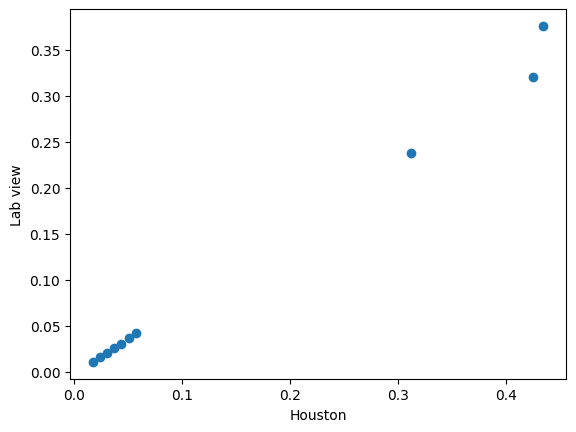

In [102]:
x = [0.057, 0.051, 0.043, 0.037, 0.030, 0.024, 0.017, 0.312, 0.435, 0.425]
y = [0.042, 0.037, 0.031, 0.026, 0.021, 0.016, 0.011, 0.238, 0.376, 0.320]
plt.scatter(x, y)
plt.xlabel("Houston")
plt.ylabel("Lab view")
plt.plot()

slope: [0.81100264], intercept: -0.004254477112426686


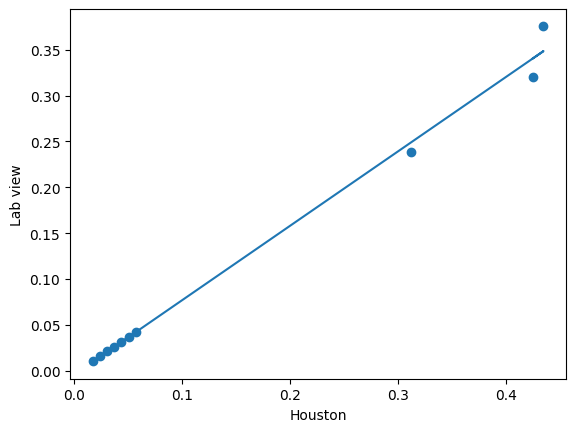

In [103]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
x1 = [[i] for i in x]
model.fit(x1, y)
slope, intercept = model.coef_, model.intercept_
plt.scatter(x, y)
plt.plot(x, slope*x+intercept)
plt.xlabel("Houston")
plt.ylabel("Lab view")
plt.plot()
print(f"slope: {slope}, intercept: {intercept}")

###2. 2D Graph

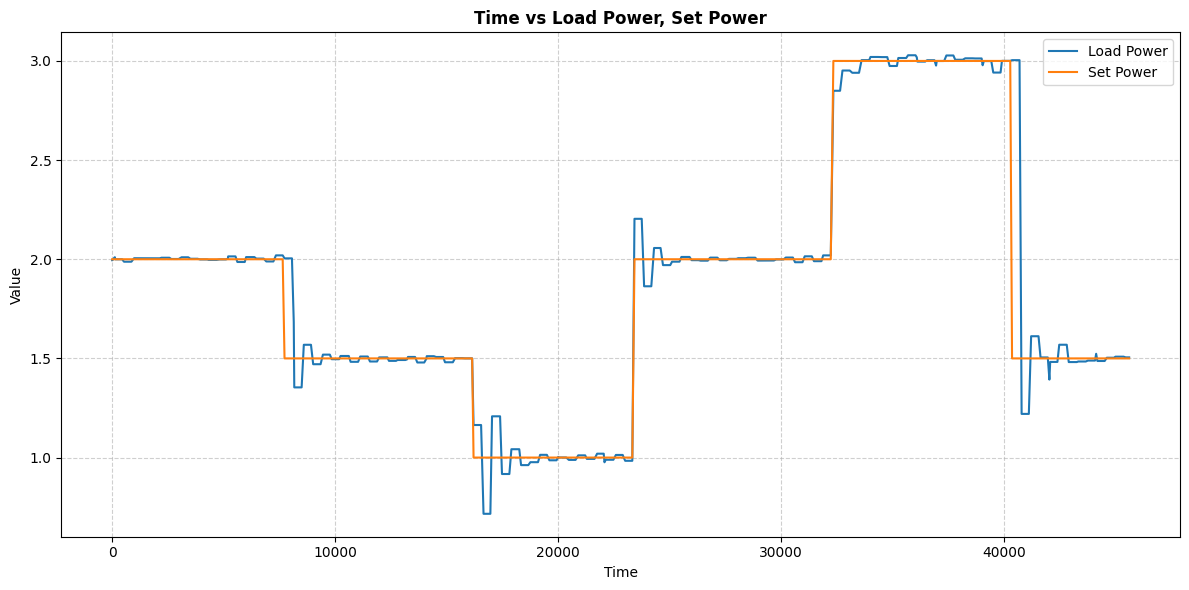

In [ ]:
#graph_2d("filename.csv")
graph_2d(load_data("data030526.csv"), "Load Power", "Set Power")

#graph_2d(load_data("pid_data3.csv"), "Load Resistance", "Set Resistance")

###3. 3D Graph

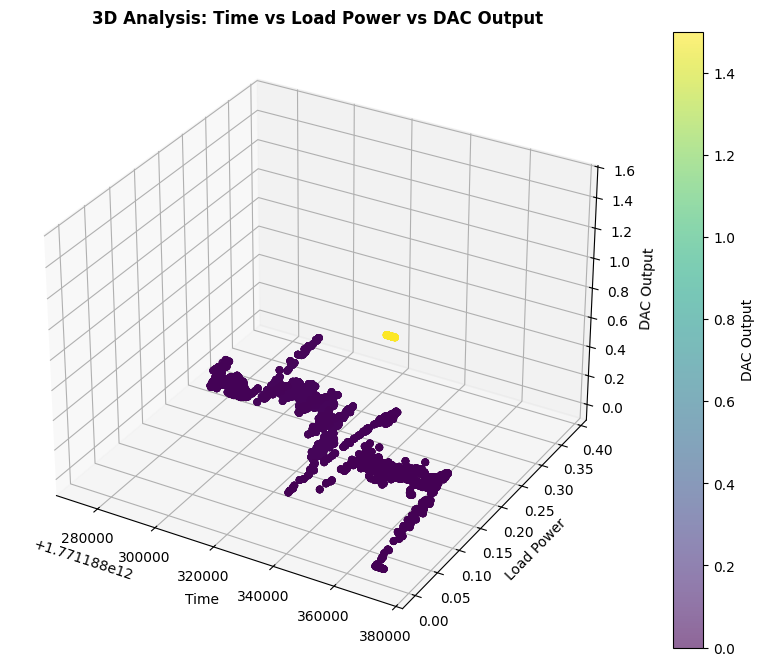

In [ ]:
graph_3d(load_data("testing_2-15-2026/test4.csv"), "Time", "Load Power", "DAC Output")

In [ ]:
graph_3dv2(load_data("constant_resistance/pid_data3.csv"), "Time", "Load Power", "DAC Output")

In [ ]:
graph_3dv2(load_data("data030526.csv"), "Time", "Load Power", "Set Power")

In [ ]:
load_data("data030526.csv")

,Time,DAC Output,K_p,Load Current,Load Power,Load Resistance,Power Mode,Resistance Mode,Set Current,Set Power,V_F1
0,1772758164999,0.123521,0.01,0.206973,1.995175,46.575233,1,0,0,2.0,0.614000
1,1772758165013,0.123521,0.01,0.206973,1.995175,46.575233,1,0,0,2.0,0.614000
2,1772758165120,0.123086,0.01,0.208207,2.010344,46.374500,1,0,0,2.0,0.615000
3,1772758165136,0.122776,0.01,0.207590,1.999903,46.408390,1,0,0,2.0,0.613625
4,1772758165137,0.122776,0.01,0.207590,1.999903,46.408390,1,0,0,2.0,0.613625
...,...,...,...,...,...,...,...,...,...,...,...
2342,1772758210549,0.088020,0.01,0.150188,1.505257,66.732971,1,0,0,1.5,0.638375
2343,1772758210563,0.088020,0.01,0.150188,1.505257,66.732971,1,0,0,1.5,0.638375
2344,1772758210580,0.088020,0.01,0.150188,1.505257,66.732971,1,0,0,1.5,0.638375
2345,1772758210599,0.088020,0.01,0.150188,1.505257,66.732971,1,0,0,1.5,0.638375


In [ ]:
po_test1 = load_data("po_data/po_test1.csv")
po_test2 = load_data("po_data/po_test2.csv")


In [ ]:
po_test1.columns

Index(['Time', 'DAC2', 'ESTOP Pressed', 'Load Current', 'Load Power',
       'Load Resistance', 'Load Voltage', 'M', 'Output Voltage', 'PCC',
       'PCC Voltage', 'Power Mode', 'Resistance Mode', 'Servo Position',
       'Set Current', 'Set Power', 'State', 'Wind Speed', 'interval time'],
      dtype='object')

In [ ]:
graph_3dv2(po_test2, "Time", "Output Voltage", "Load Voltage")

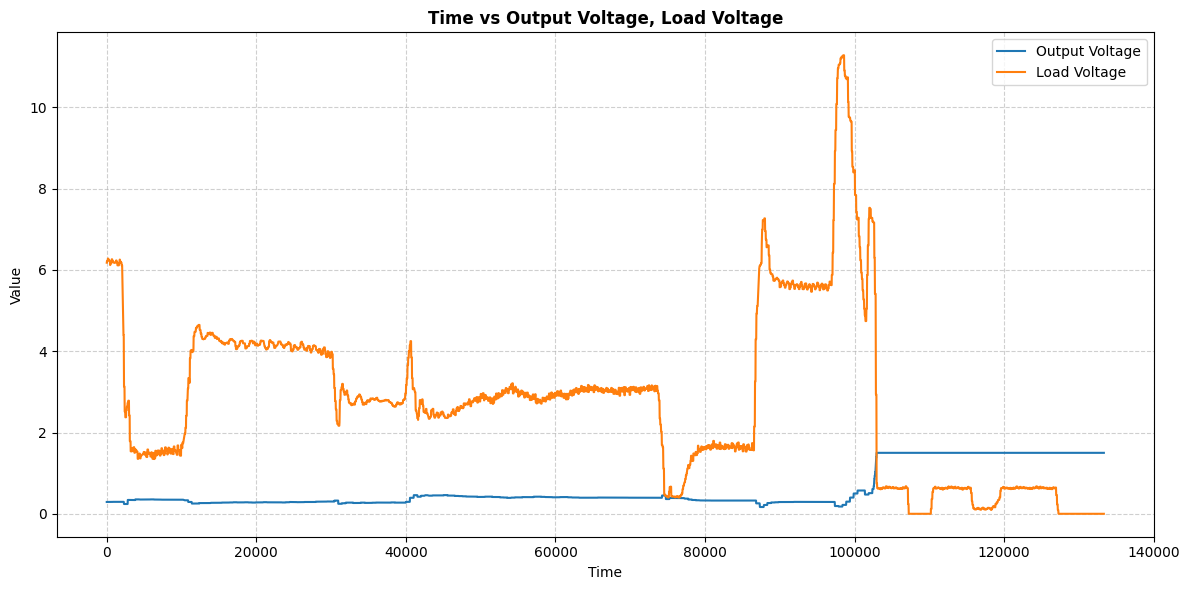

In [ ]:
graph_2d(po_test1, "Output Voltage", "Load Voltage")

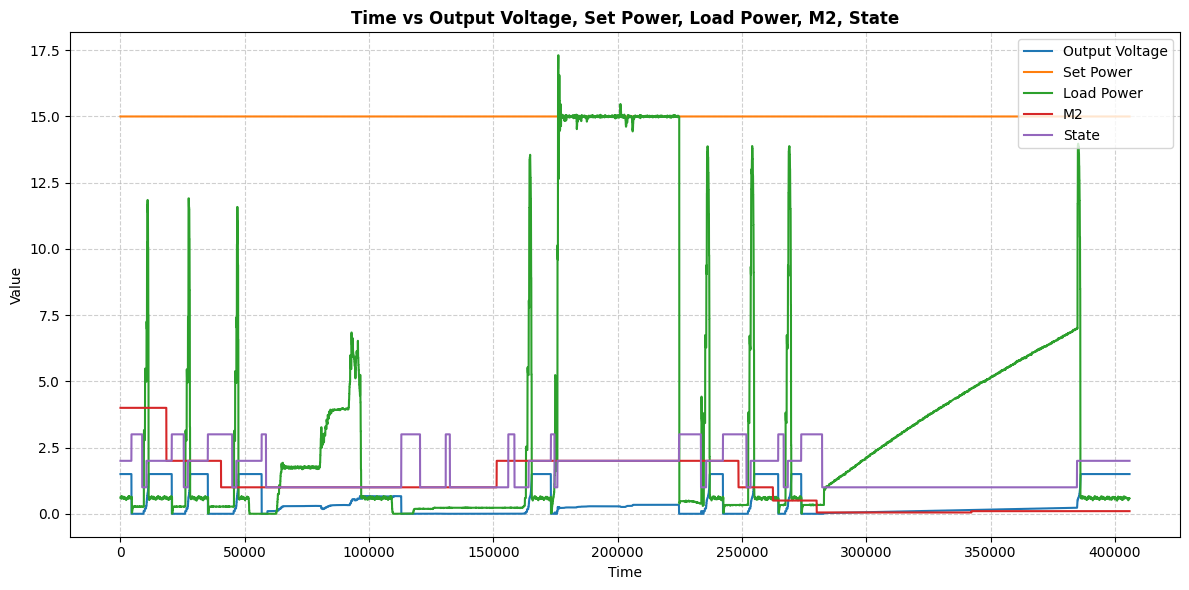

In [ ]:
po_test2["M2"] = po_test2["M"]*10
graph_2d(po_test2, "Output Voltage", "Set Power", "Load Power", "M2", "State")

---
#Score Visualization
###Task 1: Performance
|Wind Speed(m/s)|Factor|
|------|---|
|5|0.7|
|6|0.8|
|7|0.8|
|8|0.7|
|9|0.4|
|10|0.3|

###Task 2: Power Control
11~13m/s
𝑟𝑝 ≡
𝑚𝑒𝑎𝑠𝑢𝑟𝑒𝑑 𝑝𝑜𝑤𝑒𝑟 𝑖𝑛 𝑏𝑖𝑛 𝑜𝑓 𝑖𝑛𝑡𝑒𝑟𝑒𝑠𝑡 /
𝑚𝑒𝑎𝑠𝑢𝑟𝑒𝑑 𝑝𝑜𝑤𝑒𝑟 𝑎𝑡 10 𝑚/𝑠  

𝐵𝑖𝑛 𝑆𝑐𝑜𝑟𝑒 = 50
[tanh (−20 ∗ |𝑟𝑝 − 1| + 𝜋) + 1] /
[tanh (𝜋) + 1]

In [ ]:
df = load_data("constant_resistance/pid_data1.csv")
df

,Time,DAC Output,Load Current,Load Power,Load Resistance,Load Voltage,Resistance Mode,Servo Position,Set Current,Set Resistance,Sweep Pitch,V_F1,V_d,V_i,V_p,Wind Speed,pid adjustment,res error
0,1770748163655,0.0,0.008,0.015981,249.704544,1.997636,1,30,0,1000,0,0.002,0.0,0.0,-0.001,5,-0.826918,826.917847
1,1770748163664,0.0,0.008,0.015981,249.704544,1.997636,1,30,0,1000,0,0.002,0.0,0.0,-0.001,5,-0.826918,826.917847
2,1770748163668,0.0,0.008,0.015981,249.704544,1.997636,1,30,0,1000,0,0.002,0.0,0.0,-0.001,5,-0.826918,826.917847
3,1770748163681,0.0,0.008,0.015981,249.704544,1.997636,1,30,0,1000,0,0.002,0.0,0.0,-0.001,5,-0.826918,826.917847
4,1770748163686,0.0,0.008,0.015981,249.704544,1.997636,1,30,0,1000,0,0.002,0.0,0.0,-0.001,5,-0.826918,750.295471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
447,1770748167414,0.0,0.008,0.050705,792.260132,6.338081,1,30,0,1000,0,0.002,0.0,0.0,-0.001,5,-0.293289,293.289062
448,1770748167417,0.0,0.008,0.050705,792.260132,6.338081,1,30,0,1000,0,0.002,0.0,0.0,-0.001,5,-0.207740,207.739868
449,1770748167434,0.0,0.008,0.050705,792.260132,6.338081,1,30,0,1000,0,0.002,0.0,0.0,-0.001,5,-0.207740,207.739868
450,1770748167434,0.0,0.008,0.050705,792.260132,6.338081,1,30,0,1000,0,0.002,0.0,0.0,-0.001,5,-0.207740,207.739868


In [ ]:
def realtime_score(df, window_size=50, ref_10ms_power=None, threshold = 1):
    """
    Adds real-time moving statistics and instantaneous CWC expected scores to the DataFrame.

    Args:
        df: DataFrame containing 'Wind Speed' and 'Load Power' columns.
        window_size: Number of periods to calculate rolling statistics (e.g., 50 means 5 seconds at 10Hz).
        ref_10ms_power: The target stable power at 10m/s. If None, it dynamically finds the latest stable value.

    Returns:
        DataFrame with additional columns for real-time monitoring.
    """

    # 1. Map wind speed ranges to corresponding bins and factors
    conditions = [
        (df['Wind Speed'] >= 4.5) & (df['Wind Speed'] < 5.5),
        (df['Wind Speed'] >= 5.5) & (df['Wind Speed'] < 6.5),
        (df['Wind Speed'] >= 6.5) & (df['Wind Speed'] < 7.5),
        (df['Wind Speed'] >= 7.5) & (df['Wind Speed'] < 8.5),
        (df['Wind Speed'] >= 8.5) & (df['Wind Speed'] < 9.5),
        (df['Wind Speed'] >= 9.5) & (df['Wind Speed'] < 10.5),
        (df['Wind Speed'] >= 10.5) & (df['Wind Speed'] <= 13.5) # Rated Power testing range (11-13 m/s)
    ]

    bin_choices = [5, 6, 7, 8, 9, 10, 12]
    factor_choices = [0.7, 0.8, 0.8, 0.7, 0.4, 0.3, 0.0]

    df['Bin'] = np.select(conditions, bin_choices, default=0)
    df['Factor'] = np.select(conditions, factor_choices, default=0.0)

    # 2. Calculate rolling statistics to filter out sensor noise and observe steady-state
    df['Rolling_Mean_Power'] = df['Load Power'].rolling(window=window_size, min_periods=1).mean()
    df['Rolling_Std_Power'] = df['Load Power'].rolling(window=window_size, min_periods=1).std().fillna(0)

    # Calculate Coefficient of Variation (CV) to determine stability
    # # CV <= 0.05 generally indicates a mathematically stable steady-state
    # df['Realtime_CV'] = np.where(df['Rolling_Mean_Power'] > 0,
    #                              df['Rolling_Std_Power'] / df['Rolling_Mean_Power'],
    #                              0)

    # 3. Calculate instant score for the Power Curve Performance Task (5-10 m/s)
    df['Instant_PowerCurve_Score'] = df['Rolling_Mean_Power'] * df['Factor']

    # 4. Calculate instant score for the Control of Rated Power Task (11-13 m/s)
    # Dynamically locate the reference power at 10m/s if not provided
    if ref_10ms_power is None:
        valid_10ms_data = df[(df['Bin'] == 10) & (df['Rolling_Std_Power'] < threshold)]
        if not valid_10ms_data.empty:
            ref_10ms_power = valid_10ms_data['Rolling_Mean_Power'].iloc[-1]
        else:
            ref_10ms_power = 1.0 # Prevent zero-division error; actual score will evaluate to ~0

    df['Ref_10ms_Power'] = ref_10ms_power

    # Calculate power ratio (rp)
    rp = df['Rolling_Mean_Power'] / df['Ref_10ms_Power']

    # Apply the CWC scoring formula for Rated Power Control
    numerator = np.tanh(-20 * np.abs(rp - 1) + np.pi) + 1
    denominator = np.tanh(np.pi) + 1
    rated_score_raw = 50 * (numerator / denominator)

    # Assign the score only to the 11-13m/s range (Bin == 12)
    df['Instant_Rated_Score'] = np.where(df['Bin'] == 12, rated_score_raw, 0.0)

    return df


def final_score(df, cv_threshold=1):
    """
    Calculates the final official scores for the CWC Turbine Testing tasks post-run.

    Args:
        df: DataFrame containing the test run data (must include 'Wind Speed' and 'Load Power').
        cv_threshold: Maximum allowable Coefficient of Variation to be considered 'stable'.

    Returns:
        A dictionary containing the final calculated scores and reference values.
    """
    # Define bins
    conditions = [
        (df['Wind Speed'] >= 4.5) & (df['Wind Speed'] < 5.5),
        (df['Wind Speed'] >= 5.5) & (df['Wind Speed'] < 6.5),
        (df['Wind Speed'] >= 6.5) & (df['Wind Speed'] < 7.5),
        (df['Wind Speed'] >= 7.5) & (df['Wind Speed'] < 8.5),
        (df['Wind Speed'] >= 8.5) & (df['Wind Speed'] < 9.5),
        (df['Wind Speed'] >= 9.5) & (df['Wind Speed'] < 10.5),
        (df['Wind Speed'] >= 10.5) & (df['Wind Speed'] <= 13.5)
    ]
    choices = [5, 6, 7, 8, 9, 10, 12]

    df_copy = df.copy()
    df_copy['Bin'] = np.select(conditions, choices, default=0)

    power_curve_score = 0
    stable_power_10ms = None
    scores_per_bin = {}

    # =========================================================
    # Task 1: Power Curve Performance Task (5 - 10 m/s)
    # =========================================================
    factors = {5: 0.7, 6: 0.8, 7: 0.8, 8: 0.7, 9: 0.4, 10: 0.3}

    for bin_ws in [5, 6, 7, 8, 9, 10]:
        bin_data = df_copy[df_copy['Bin'] == bin_ws]['Load Power']

        if len(bin_data) == 0:
            scores_per_bin[bin_ws] = 0
            continue

        mean_p = bin_data.mean()
        std_p = bin_data.std()

        # Check stability based on the CV threshold
        if mean_p > 0 and (std_p) <= cv_threshold:
            # Power is stable; calculate score
            bin_score = mean_p * factors[bin_ws]
            scores_per_bin[bin_ws] = bin_score
            power_curve_score += bin_score

            # Store the 10m/s power to use as a baseline for Task 2
            if bin_ws == 10:
                stable_power_10ms = mean_p
        else:
            # Power is unstable; score is zero
            scores_per_bin[bin_ws] = 0

    # =========================================================
    # Task 2: Control of Rated Power Task (11 - 13 m/s)
    # =========================================================
    rated_power_score = 0
    high_wind_data = df_copy[df_copy['Bin'] == 12]['Load Power']

    # Evaluate only if the 10m/s baseline is established and high wind data exists
    if stable_power_10ms is not None and len(high_wind_data) > 0:
        mean_high_p = high_wind_data.mean()

        # Calculate the ratio (rp) of measured power to the 10m/s baseline
        rp = mean_high_p / stable_power_10ms

        # Apply the official tanh scoring formula
        numerator = np.tanh(-20 * abs(rp - 1) + np.pi) + 1
        denominator = np.tanh(np.pi) + 1
        rated_power_score = 50 * (numerator / denominator)

    return {
        "Total Power Curve Score (Max 50+)": round(power_curve_score, 5),
        "Control of Rated Power Score (Max 50)": round(rated_power_score, 5),
        "10m/s Reference Power (W)": round(stable_power_10ms, 5) if stable_power_10ms else None,
        "Detailed Power Curve Bin Scores": {k: float(round(v, 5)) for k, v in scores_per_bin.items()}
    }

# Workflow Example:
# 1. Update real-time signals during the run for debugging/dashboard
# df_realtime = add_realtime_score_columns(raw_sensor_df, window_size=50)

# 2. Extract official final scores after the run finishes
# final_results = calculate_cwc_final_scores(df_realtime, cv_threshold=0.05)

In [ ]:
newdf=realtime_score(df)

In [ ]:
for k, v in final_score(df).items():
    print(k,":", v)

Total Power Curve Score (Max 50+) : 0.30403
Control of Rated Power Score (Max 50) : 0
10m/s Reference Power (W) : None
Detailed Power Curve Bin Scores : {5: 0.30403, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0.0, 10: 0.0}


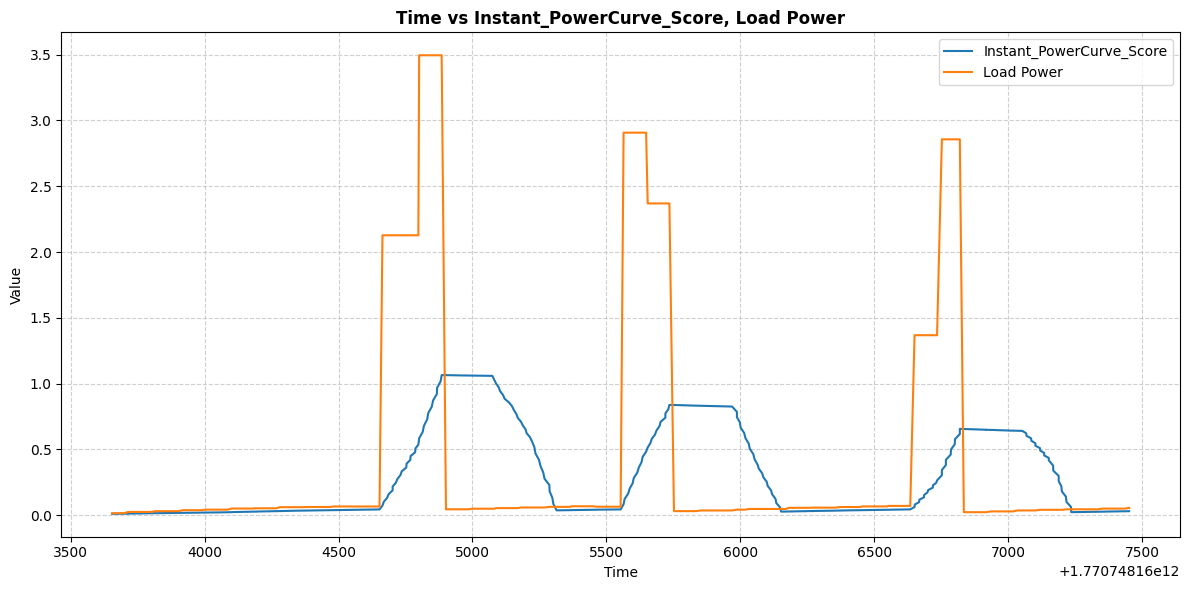

In [ ]:
graph_2d(newdf,"Instant_PowerCurve_Score", "Load Power")

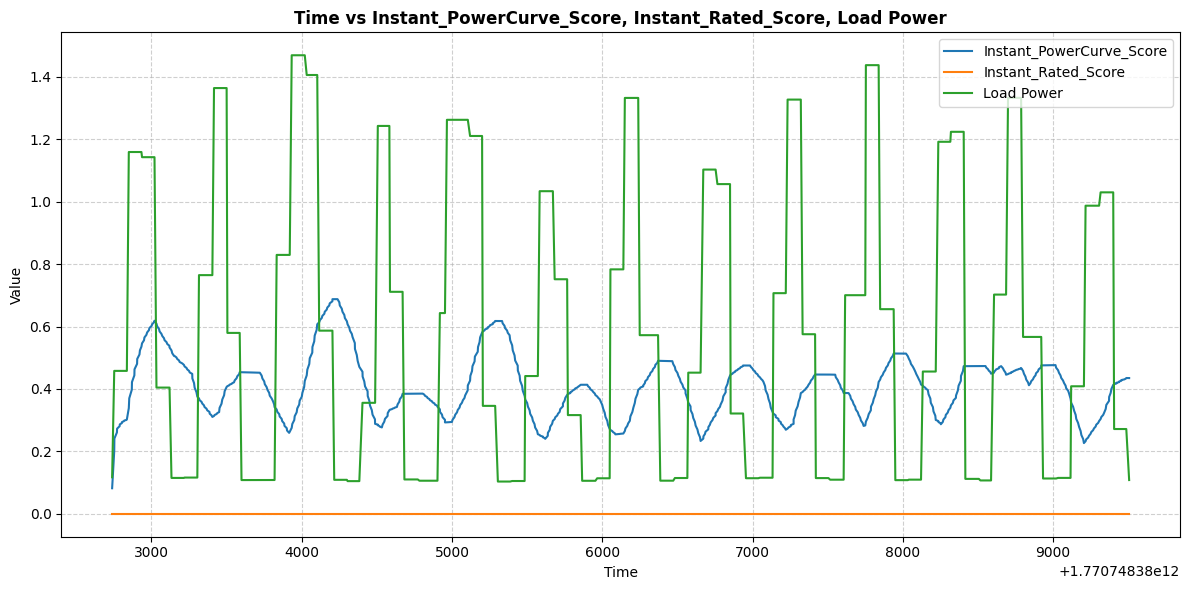

Total Power Curve Score (Max 50+) : 0.40958
Control of Rated Power Score (Max 50) : 0
10m/s Reference Power (W) : None
Detailed Power Curve Bin Scores : {5: 0.40958, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0.0, 10: 0.0}


In [ ]:
newdf2 = realtime_score(load_data("constant_resistance/pid_data2.csv"))
graph_2d(newdf2, "Instant_PowerCurve_Score", "Instant_Rated_Score", "Load Power")
for k, v in final_score(newdf2).items():
    print(k,":", v)


In [ ]:
def load_data(f):
    return pd.read_csv("/content/drive/MyDrive/WEC_Electronics/Data/"+f)

def graph_2d(df, *vars):
    plt.figure(figsize=(12, 6))
    for col in vars:
        plt.plot(df["Time"], df[col], label=col, linewidth=1.5)
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title(f"Time vs {', '.join(vars)}", fontweight='bold')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def graph_3d(df, x_col, y_col, z_col):

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # 3D Scatter plot (Color mapped to the Z-axis variable)
    sc = ax.scatter(df[x_col], df[y_col], df[z_col],
                    c=df[z_col], cmap='viridis', s=20, alpha=0.6)

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_zlabel(z_col)
    plt.title(f'3D Analysis: {x_col} vs {y_col} vs {z_col}', fontweight='bold')

    # Add a color bar
    plt.colorbar(sc, label=z_col)
    plt.show()

#Processing

In [ ]:
load_data("constant_resistance/pid_data1.csv")

,Time,DAC Output,Load Current,Load Power,Load Resistance,Load Voltage,Resistance Mode,Servo Position,Set Current,Set Resistance,Sweep Pitch,V_F1,V_d,V_i,V_p,Wind Speed,pid adjustment,res error
0,0,0.0,0.008,0.015981,249.704544,1.997636,1,30,0,1000,0,0.002,0.0,0.0,-0.001,5,-0.826918,826.917847
1,9,0.0,0.008,0.015981,249.704544,1.997636,1,30,0,1000,0,0.002,0.0,0.0,-0.001,5,-0.826918,826.917847
2,13,0.0,0.008,0.015981,249.704544,1.997636,1,30,0,1000,0,0.002,0.0,0.0,-0.001,5,-0.826918,826.917847
3,26,0.0,0.008,0.015981,249.704544,1.997636,1,30,0,1000,0,0.002,0.0,0.0,-0.001,5,-0.826918,826.917847
4,31,0.0,0.008,0.015981,249.704544,1.997636,1,30,0,1000,0,0.002,0.0,0.0,-0.001,5,-0.826918,750.295471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
447,3759,0.0,0.008,0.050705,792.260132,6.338081,1,30,0,1000,0,0.002,0.0,0.0,-0.001,5,-0.293289,293.289062
448,3762,0.0,0.008,0.050705,792.260132,6.338081,1,30,0,1000,0,0.002,0.0,0.0,-0.001,5,-0.207740,207.739868
449,3779,0.0,0.008,0.050705,792.260132,6.338081,1,30,0,1000,0,0.002,0.0,0.0,-0.001,5,-0.207740,207.739868
450,3779,0.0,0.008,0.050705,792.260132,6.338081,1,30,0,1000,0,0.002,0.0,0.0,-0.001,5,-0.207740,207.739868


In [ ]:
processing(load_data("constant_resistance/pid_data1.csv"))

/tmp/ipykernel_6849/1431020156.py:36: FutureWarning:

'L' is deprecated and will be removed in a future version, please use 'ms' instead.



,Time,DAC Output,Load Current,Load Power,Load Resistance,Load Voltage,Resistance Mode,Servo Position,Set Current,Set Resistance,Sweep Pitch,V_F1,V_d,V_i,V_p,Wind Speed,pid adjustment,res error
0,0.049000,0.0,0.008000,0.020317,294.872996,2.358984,1.0,30.0,0.0,1000.0,0.0,0.002,0.0,0.0,-0.001,5.0,-0.779766,773.871587
1,0.153083,0.0,0.008000,0.028288,426.836853,3.475365,1.0,30.0,0.0,1000.0,0.0,0.002,0.0,0.0,-0.001,5.0,-0.627964,627.964233
2,0.211000,0.0,0.008000,0.031200,487.506531,3.900053,1.0,30.0,0.0,1000.0,0.0,0.002,0.0,0.0,-0.001,5.0,-0.603498,603.497986
3,0.362900,0.0,0.008200,0.041898,614.428662,5.022459,1.0,30.0,0.0,1000.0,0.0,0.002,0.0,0.0,-0.001,5.0,-0.464854,464.854248
4,0.411500,0.0,0.008000,0.042706,667.283936,5.338272,1.0,30.0,0.0,1000.0,0.0,0.002,0.0,0.0,-0.001,5.0,-0.332716,332.716064
5,0.558909,0.0,0.008136,0.052769,796.979520,6.472616,1.0,30.0,0.0,1000.0,0.0,0.002,0.0,0.0,-0.001,5.0,-0.279376,279.376271
6,0.558909,0.0,0.008136,0.052769,796.979520,6.472616,1.0,30.0,0.0,1000.0,0.0,0.002,0.0,0.0,-0.001,5.0,-0.279376,279.376271
7,0.754833,0.0,0.008083,0.062647,960.567698,7.755471,1.0,30.0,0.0,1000.0,0.0,0.002,0.0,0.0,-0.001,5.0,-0.126970,126.970103
8,0.841111,0.0,0.008000,0.065975,1030.861220,8.246890,1.0,30.0,0.0,1000.0,0.0,0.002,0.0,0.0,-0.001,5.0,-0.017548,17.547852
9,0.841111,0.0,0.008000,0.065975,1030.861220,8.246890,1.0,30.0,0.0,1000.0,0.0,0.002,0.0,0.0,-0.001,5.0,-0.017548,17.547852


In [ ]:
graph_3dv2(load_data("constant_resistance/pid_data1.csv"), "Time", "Load Power", "Load Current")

#PID constant
* I'll try to estimate the wind speed with voltage and rpm and fit the PID constants for each wind speed.

In [ ]:


# ---------------------------------------------------------
# 1. Data Loading & Preprocessing
# ---------------------------------------------------------
def load_data(f):
    df = pd.read_csv(f)
    df["Time"] = (df["Time"] - df["Time"].iloc[0])
    return df

def processed_csv(f, resample_interval='100ms'):
    df_clean = load_data(f).copy()
    df_clean["Time"] = df_clean["Time"] / 1000.0
    df_clean['Timedelta'] = pd.to_timedelta(df_clean['Time'], unit='s')
    df_clean = df_clean.set_index('Timedelta')
    df_clean = df_clean.drop(columns=['Time'])

    df_resampled = df_clean.resample(resample_interval).mean().interpolate()
    df_resampled['Time'] = df_resampled.index.total_seconds()
    df_resampled = df_resampled.reset_index(drop=True)

    cols = ['Time'] + [c for c in df_resampled.columns if c != 'Time']
    return df_resampled[cols]

# ---------------------------------------------------------
# 2. Sensorless Wind Speed Estimation Model (Degree = 3)
# ---------------------------------------------------------
def build_wind_estimator(df_all, degree=2):
    # Features: Load Voltage (V), Load Current (I), DAC Output (D)
    X = df_all[['Load Voltage', 'Load Current', 'DAC Output']]
    y = df_all['Wind Speed']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Polynomial Expansion
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Linear Regression Fit
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Evaluation
    y_pred = model.predict(X_test_poly)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("\n=== Wind Speed Estimator Performance ===")
    print(f"Polynomial Degree: {degree}")
    print(f"MSE: {mse:.4f}")
    print(f"R-squared: {r2:.4f}")

    # Extract Coefficients for C/C++ Porting
    feature_names = poly.get_feature_names_out(['V', 'I', 'D'])
    print("\n=== Coefficients for ESP32 C++ Code ===")
    print(f"const float INTERCEPT = {model.intercept_:.6f};")
    for name, coef in zip(feature_names, model.coef_):
        # Format names for C++ (e.g., 'V^2' -> 'V2', 'V I' -> 'V_I')
        safe_name = name.replace('^', '').replace(' ', '_')
        print(f"const float W_{safe_name} = {coef:.6f};")

    return model, poly

# ---------------------------------------------------------
# 3. Gain Scheduling: PID Tuning by Wind Speed Bins
# ---------------------------------------------------------
def simulate_pid_power(params, time_arr, target_power, initial_power):
    kp, ki, kd = params
    n = len(time_arr)
    simulated_power = np.zeros(n)
    simulated_power[0] = initial_power

    error_sum = 0.0
    last_error = 0.0

    for i in range(1, n):
        dt = time_arr[i] - time_arr[i-1]
        if dt <= 0: dt = 1e-4

        error = target_power - simulated_power[i-1]
        error_sum += error * dt
        derivative = (error - last_error) / dt

        control_out = (kp * error) + (ki * error_sum) + (kd * derivative)

        # Simple First-Order plant approximation for power response
        simulated_power[i] = simulated_power[i-1] + (control_out * dt)
        last_error = error

    return simulated_power

def objective_function(params, time_arr, target_power, measured_power_arr):
    simulated = simulate_pid_power(params, time_arr, target_power, measured_power_arr[0])
    # Objective: Minimize MSE between Target Power and Simulated Power
    mse = np.mean((target_power - simulated)**2)
    return mse

def fit_pid_for_bins(df_all):
    # Calculate Target Power at 10m/s for Task 2 (11-13m/s regulation)
    df_10 = df_all[(df_all['Wind Speed'] >= 9.8) & (df_all['Wind Speed'] <= 10.2)]
    target_power_10ms = df_10['Load Power'].mean() if not df_10.empty else 10.0

    bins = {
        "Bin_5_7": df_all[(df_all['Wind Speed'] >= 5) & (df_all['Wind Speed'] < 8)],
        "Bin_8_10": df_all[(df_all['Wind Speed'] >= 8) & (df_all['Wind Speed'] <= 10)],
        "Bin_11_13": df_all[(df_all['Wind Speed'] >= 11) & (df_all['Wind Speed'] <= 13)]
    }

    print("\n=== PID Optimization Results by Bin ===")
    initial_guess = [0.5, 0.1, 0.01]
    bounds = ((0, None), (0, None), (0, None))

    for bin_name, df_bin in bins.items():
        if df_bin.empty:
            continue

        time_arr = df_bin['Time'].values
        measured_power = df_bin['Load Power'].values

        # Determine target based on Task rules
        if bin_name == "Bin_11_13":
            target_power = target_power_10ms # Regulate to 10m/s power
        else:
            target_power = measured_power.mean() # Simplified target for lower bins

        res = minimize(
            objective_function,
            initial_guess,
            args=(time_arr, target_power, measured_power),
            method='L-BFGS-B',
            bounds=bounds
        )

        print(f"[{bin_name}] Target Power: {target_power:.2f}W")
        print(f"  -> Kp: {res.x[0]:.4f}, Ki: {res.x[1]:.4f}, Kd: {res.x[2]:.4f} (MSE: {res.fun:.4f})")

# ---------------------------------------------------------
# Main Execution
# ---------------------------------------------------------
if __name__ == "__main__":
    # 데이터 경로를 실제 환경에 맞게 수정해야 해
    # file_list = glob.glob("/content/drive/MyDrive/WEC_Electronics/Data/*.csv")

    # 데모용 가상 데이터 생성 (실행 확인용)
    np.random.seed(42)
    dummy_data = pd.DataFrame({
        'Time': np.linspace(0, 100000, 1000),
        'Load Voltage': np.random.uniform(5, 15, 1000),
        'Load Current': np.random.uniform(0.5, 3.0, 1000),
        'DAC Output': np.random.uniform(0, 4095, 1000),
        'Load Power': np.random.uniform(10, 45, 1000),
        'Wind Speed': np.random.uniform(5, 13, 1000)
    })

    # 1. 3차 모델 학습 및 평가
    model, poly = build_wind_estimator(dummy_data, degree=3)

    # 2. 구간별 PID 피팅
    fit_pid_for_bins(dummy_data)


=== Wind Speed Estimator Performance ===
Polynomial Degree: 3
MSE: 5.4574
R-squared: -0.0309


ValueError: input_features is not equal to feature_names_in_